<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/Teacher_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 · Teacher Comparison

Loads the best checkpoint for each teacher candidate and compares:
accuracy, parameter count, model size, and inference latency.

**Expected outcome:** ResNet18 (pretrained) wins on accuracy with a favourable
parameters/accuracy tradeoff. VGG16-BN may match accuracy but at 12× the parameter cost.

⚠️  Update the checkpoint paths below after running notebooks 01–04.


In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders, get_test_loader
from utils.models  import (
    VGG_Scratch, VGG_Pretrained,
    ResNet_Scratch, ResNet18_Pretrained,
    MobileNetV2_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, MODEL_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_model, train_model_three_phase,
    train_multi_seed, train_kd, plot_history,
)

device = setup_device(seed=41)


Device: cpu


In [3]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

In [4]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [8]:
# ── Update these after running notebooks 01–04 ──────────────────────
# Replace seed_XX with your best seed number for each model
TEACHER_CKPTS = {
    "VGG (scratch)":         (VGG_Scratch,          f"{SAVE_DIR}/vgg_scratch_seed_41.pth"),
    "VGG16-BN (pretrained)": (VGG_Pretrained,        f"{SAVE_DIR}/vgg_pretrained_seed_63.pth"),
    "ResNet (scratch)":      (ResNet_Scratch,         f"{SAVE_DIR}/resnet_scratch_seed_41.pth"),
    "ResNet18 (pretrained)": (ResNet18_Pretrained,    f"{SAVE_DIR}/resnet18_pretrained_seed_52.pth"),
}


In [9]:
_, val_loader = get_loaders(batch_size=64)

def measure_latency(model, device, runs=200, warmup=20):
    model.eval()
    dummy = torch.randn(1, 3, 96, 96, device=device)
    with torch.no_grad():
        for _ in range(warmup): model(dummy)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(runs): model(dummy)
        if device.type == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / runs * 1000   # ms

rows = []
for name, (fn, ckpt) in TEACHER_CKPTS.items():
    if not os.path.exists(ckpt):
        print(f"⚠️  Skipping {name} — checkpoint not found"); continue
    m = fn().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    acc  = evaluate(m, val_loader, device)
    tp,_ = count_params(m)
    size = model_size_mb(m)
    lat  = measure_latency(m, device)
    rows.append({"Model": name, "Val Acc (%)": round(acc*100, 2),
                 "Params (M)": round(tp/1e6, 2), "Size (MB)": round(size, 2),
                 "Latency (ms)": round(lat, 3)})
    print(f"{name:28s}  acc={acc*100:.2f}%  params={tp/1e6:.2f}M  "
          f"size={size:.2f}MB  lat={lat:.3f}ms")


Train: 7000 | Val: 1500 | Batch: 64


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


VGG (scratch)                 acc=80.27%  params=5.96M  size=23.86MB  lat=38.551ms
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:09<00:00, 59.0MB/s]


VGG16-BN (pretrained)         acc=88.07%  params=27.63M  size=110.60MB  lat=144.827ms
ResNet (scratch)              acc=77.80%  params=2.83M  size=11.37MB  lat=86.886ms
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


ResNet18 (pretrained)         acc=85.47%  params=11.24M  size=45.05MB  lat=33.407ms


In [10]:
import pandas as pd
df = pd.DataFrame(rows).set_index("Model")
print("\n" + df.to_string())

winner = df["Val Acc (%)"].idxmax()
print(f"\n🏆 Selected teacher: {winner}  ({df.loc[winner,'Val Acc (%)']:.2f}%)")
print("   → Set TEACHER_CKPT in notebooks 09 and 10")


                       Val Acc (%)  Params (M)  Size (MB)  Latency (ms)
Model                                                                  
VGG (scratch)                80.27        5.96      23.86        38.551
VGG16-BN (pretrained)        88.07       27.63     110.60       144.827
ResNet (scratch)             77.80        2.83      11.37        86.886
ResNet18 (pretrained)        85.47       11.24      45.05        33.407

🏆 Selected teacher: VGG16-BN (pretrained)  (88.07%)
   → Set TEACHER_CKPT in notebooks 09 and 10


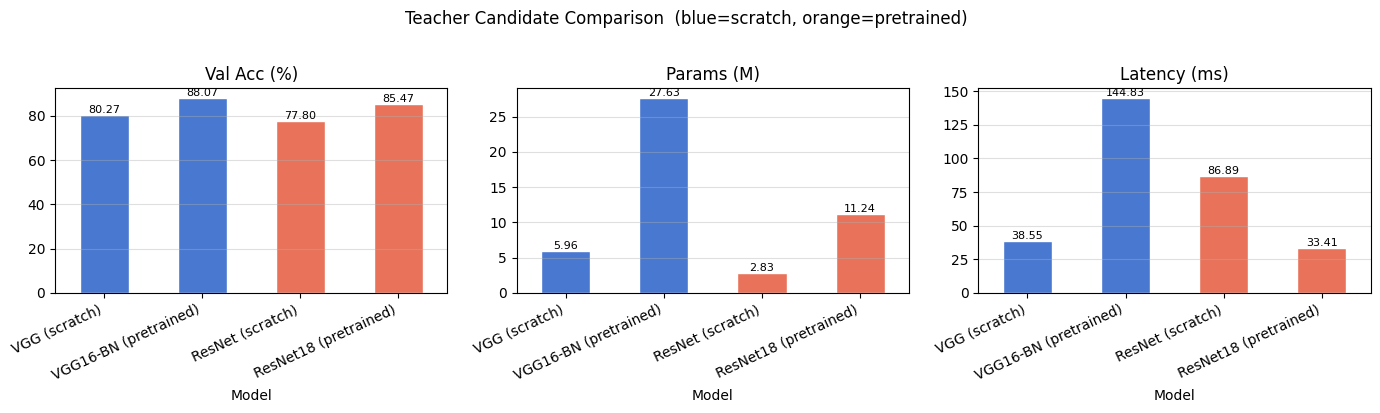

In [11]:
# ── Comparison charts ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#4878D0", "#4878D0", "#E8735A", "#E8735A"]   # blue=scratch, orange=pretrained

for ax, col in zip(axes, ["Val Acc (%)", "Params (M)", "Latency (ms)"]):
    bars = df[col].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
    ax.set_title(col); ax.set_xticklabels(df.index, rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.4)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x()+p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Teacher Candidate Comparison  (blue=scratch, orange=pretrained)", y=1.02)
plt.tight_layout();
plt.show()